# I'm gonna run a test model here before diving deep into the ultimate model

## I. Introduction
This document only focus on a simple ML model using lightgbm to test the dataset.
I will note my progress making and trying simple model (only use libraries and modules) step-by-step.


## II, Tutorial
### Step 1: Import library.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import json
from datetime import datetime

### Step 2:Prepare the dataset

In [2]:
file_path = r'G:\url-analysis\src\data\new_url_updated.csv'
url_data = pd.read_csv(file_path, encoding_errors='ignore')
url_data.info()

print(url_data.isnull().sum())
print("\nPhân phối nhãn:")
print(url_data['type'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 672186 entries, 0 to 672185
Data columns (total 61 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   url                               672186 non-null  str    
 1   type                              672186 non-null  str    
 2   url length                        672186 non-null  int64  
 3   number_of_part                    672186 non-null  int64  
 4   has_scheme                        672186 non-null  int64  
 5   has_netloc                        672186 non-null  int64  
 6   has_path                          672186 non-null  int64  
 7   has_params                        672186 non-null  int64  
 8   has_query                         672186 non-null  int64  
 9   has_fragment                      672186 non-null  int64  
 10  has_username                      672186 non-null  int64  
 11  has_password                      672186 non-null  int64  
 12 

### Step 3: split the dataset, X is the set of features used to test, y is the label

In [3]:
X = pd.DataFrame(url_data).drop(columns = ['url', 'type'])
print(X.head())

# y is the tag for supervised learning
y = url_data.type
print(y)

   url length  number_of_part  has_scheme  has_netloc  has_path  has_params  \
0          16               1           0           1         0           0   
1          35               2           0           1         1           0   
2          31               2           0           1         1           0   
3          88               4           1           1         1           0   
4         235               4           1           1         1           0   

   has_query  has_fragment  has_username  has_password  ...  \
0          0             0             0             0  ...   
1          0             0             0             0  ...   
2          0             0             0             0  ...   
3          1             0             0             0  ...   
4          1             0             0             0  ...   

   suspicious_key_domain  suspicious_key_subdomain  suspicious_key_path  \
0                      0                         0                    0

### Step 4: write loss_function

In [4]:
def loss_function():
    pass
def gradient_descent():
    pass
def hessian():
    pass

### Step 5: split X, y to X_train, X_test, y_train, y_test, X_val, y_val to train and test using LightGBM model

In [5]:

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.15, stratify=y, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.177, stratify=y_temp, random_state = 42)
print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)


params = {
    'objective' : 'multiclass',
    'class_weight' : 'balanced',
    'n_estimators' : 8000,
    'num_class' : 4,
    'boosting_type' : 'gbdt',
    'learning_rate' : 0.02,
    'verbose' : -1,
    'random_state' : 42,
    'colsample_bytree' : 0.75,
    'max_depth' : 7,
    'num_leaves' : 32,
    'min_data_in_leaf' : 30,
    'early_stopping_rounds' : 100,
    'n_jobs' : -1
}

model_classification = lgb.LGBMClassifier(**params)

callbacks = [lgb.early_stopping(stopping_rounds=50,verbose=True), lgb.log_evaluation(100)]
model_classification.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names = ['train', 'val'],
    callbacks=callbacks,
    eval_metric=['multi_logloss', 'auc_mu']
)
print(f"Best iteration: {model_classification.best_iteration_}")

Train: 470227 | Validation: 101131 | Test: 100828
Training until validation scores don't improve for 50 rounds
[100]	train's multi_logloss: 0.314825	train's auc_mu: 0.99187	val's multi_logloss: 0.287454	val's auc_mu: 0.991457
[200]	train's multi_logloss: 0.223758	train's auc_mu: 0.994496	val's multi_logloss: 0.20289	val's auc_mu: 0.994118
[300]	train's multi_logloss: 0.193681	train's auc_mu: 0.995588	val's multi_logloss: 0.177361	val's auc_mu: 0.995219
[400]	train's multi_logloss: 0.175921	train's auc_mu: 0.996215	val's multi_logloss: 0.163773	val's auc_mu: 0.995807
[500]	train's multi_logloss: 0.163209	train's auc_mu: 0.996661	val's multi_logloss: 0.154282	val's auc_mu: 0.996199
[600]	train's multi_logloss: 0.153308	train's auc_mu: 0.997008	val's multi_logloss: 0.147238	val's auc_mu: 0.996474
[700]	train's multi_logloss: 0.145526	train's auc_mu: 0.99726	val's multi_logloss: 0.142083	val's auc_mu: 0.996672
[800]	train's multi_logloss: 0.13864	train's auc_mu: 0.997482	val's multi_loglos

#### Display the learning curve of train and validation

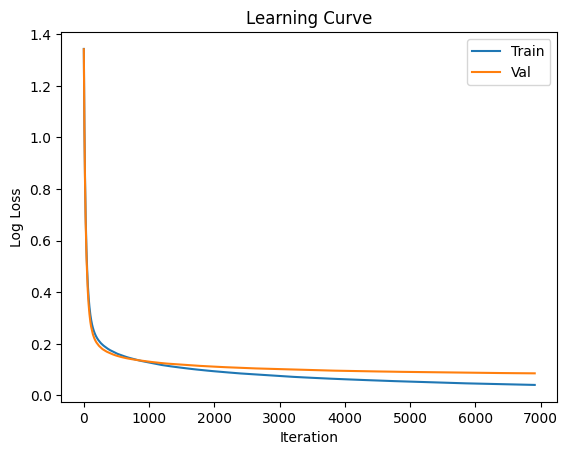

In [6]:
results = model_classification.evals_result_
plt.plot(results['train']['multi_logloss'], label='Train')
plt.plot(results['val']['multi_logloss'],   label='Val')
plt.xlabel('Iteration'); plt.ylabel('Log Loss')
plt.legend(); plt.title('Learning Curve'); plt.show()

In [7]:
y_pred = model_classification.predict_proba(X_test)
y_pred_classes = np.argmax(y_pred, axis = 1)


print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===")
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Độ chính xác (Accuracy): {accuracy:.4f}\n")

# In ra Classification Report chi tiết (Precision, Recall, F1-score)
# Sử dụng le.classes_ để map ngược lại tên chuỗi ban đầu (phishing, benign, malware, defacement)
print("Báo cáo phân loại chi tiết:")
print(classification_report(y_test,y_pred_classes, target_names=le.classes_))

# metadata của model
metadata = {
    'accuracy': float(accuracy),
    'best_iteration': model_classification.best_iteration_,
    'params': params,
    'features': X.columns.tolist(),
    'classes': le.classes_.tolist(),
    'trained_at': datetime.now().isoformat(),
    'n_train': len(X_train), 'n_val': len(X_val), 'n_test': len(X_test)
}

# lưu model bằng file json
model_filename = 'lgb_url_classifier_metadata.json'
with open(model_filename, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Đã lưu mô hình + metadata thành công tại: {model_filename}")

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===
Độ chính xác (Accuracy): 0.9734

Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

      benign       0.99      0.98      0.98     64215
  defacement       0.98      1.00      0.99     14469
     malware       0.99      0.97      0.98      7682
    phishing       0.90      0.93      0.91     14462

    accuracy                           0.97    100828
   macro avg       0.96      0.97      0.97    100828
weighted avg       0.97      0.97      0.97    100828

Đã lưu mô hình + metadata thành công tại: lgb_url_classifier_metadata.json


### Step 6: Display the confusion matrix

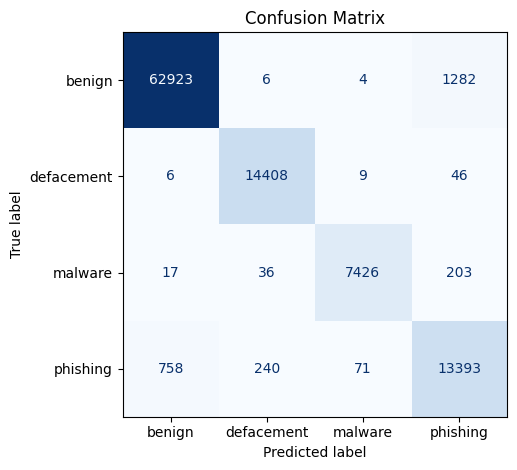

In [8]:
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Step 7: Check the importance of feature

['url', 'type', 'url length', 'number_of_part', 'has_scheme', 'has_netloc', 'has_path', 'has_params', 'has_query', 'has_fragment', 'has_username', 'has_password', 'has_port', 'has_subdomain', 'has_domain', 'has_suffix', 'netloc_length', 'path_length', 'query_length', 'fragment_length', 'subdomain_length', 'domain_length', 'url_entropy', 'netloc_entropy', 'path_entropy', 'query_entropy', 'subdomain_entropy', 'domain_entropy', 'number_of_subdomain', 'hyphen_in_subdomain', 'hyphen_in_domain', 'unicode', 'punycode', 'at_sign_in_netloc', 'slash_in_path', 'dot_in_path', 'strange_in_query', 'equal_in_query', 'ampersand_in_query', 'number_subdomain', 'normalized_levenshtein_domain', 'normalized_levenshtein_subdomain', 'random_domain_check', 'random_subdomain_check', 'number_ratio_domain', 'number_ratio_subdomain', 'repeated_domain_check', 'repeated_path_check', 'repeated_url_check', 'longest_repeated_chain', 'ip_domain', 'suspicious_key_domain', 'suspicious_key_subdomain', 'suspicious_key_path

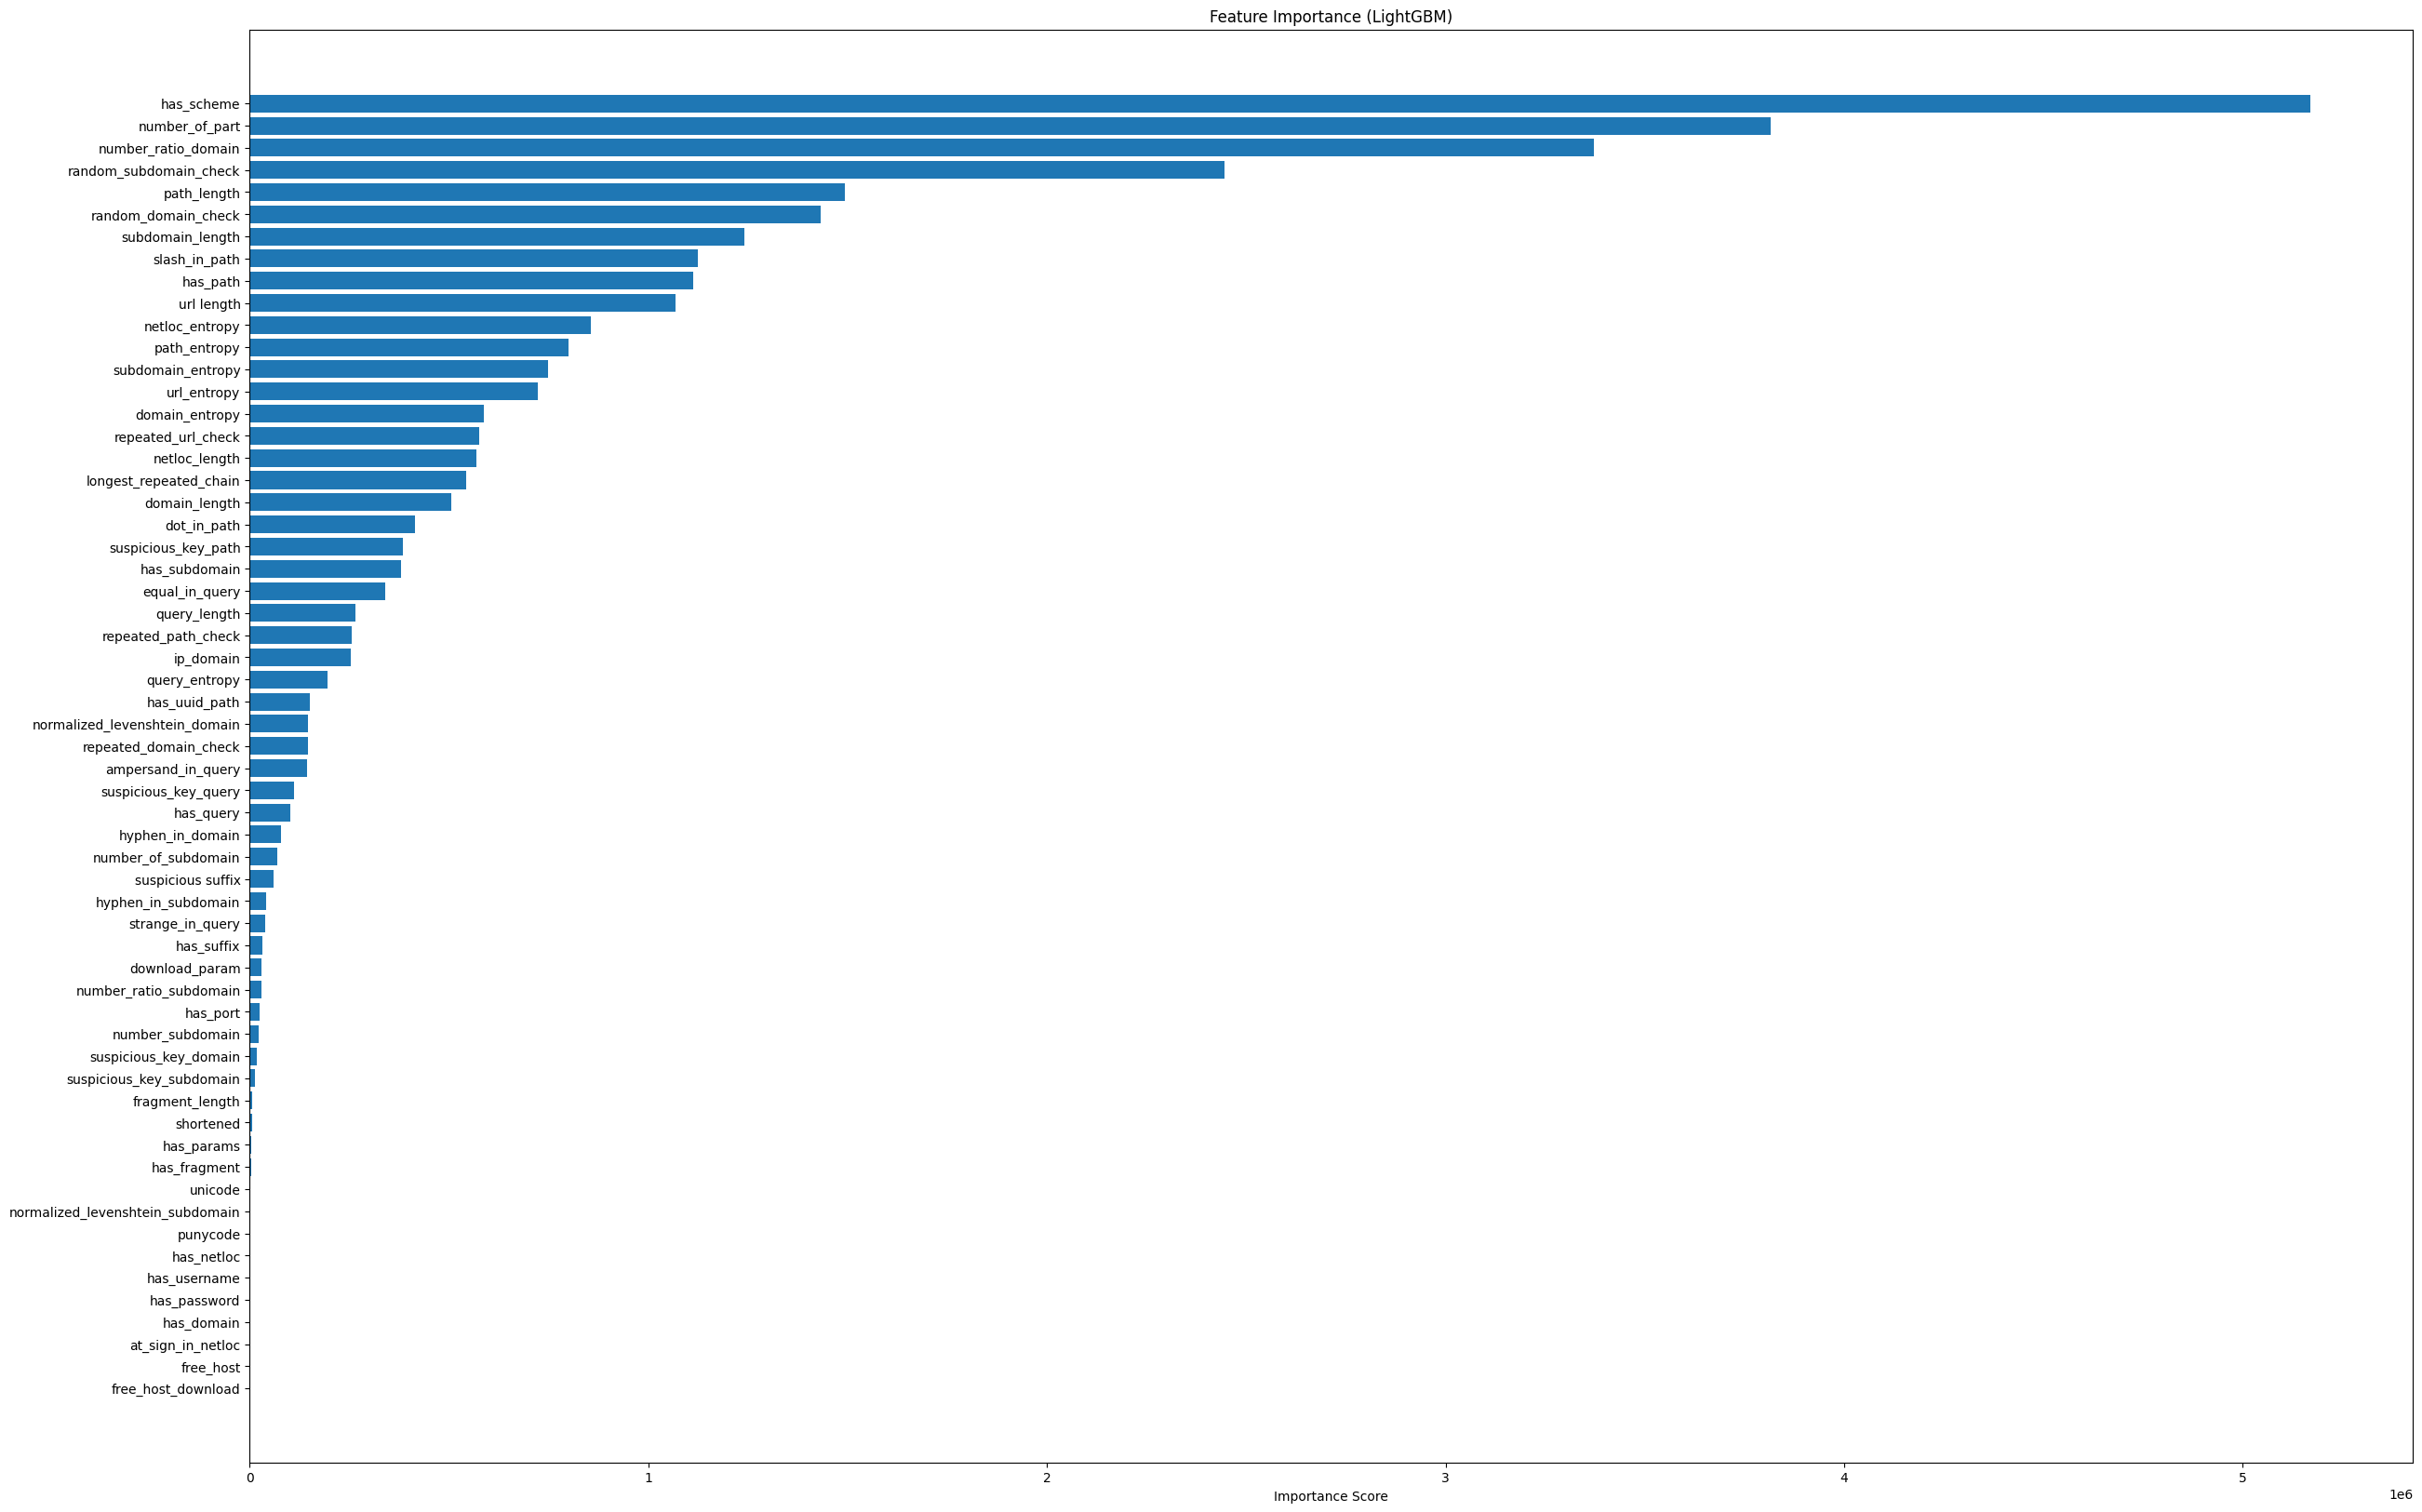

In [9]:
col_list = url_data.columns.tolist()
print(col_list)

importances = model_classification.booster_.feature_importance(importance_type = 'gain')
importance_df = pd.DataFrame(
    {
        "feature" : X.columns,
        "importance" : importances
    }
).sort_values(by="importance", ascending = False)
print(importance_df)

plt.figure(figsize=(30,20))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (LightGBM)")
plt.xlabel("Importance Score")
plt.show()

### Step 7: SHAP analysis


--- benign ---


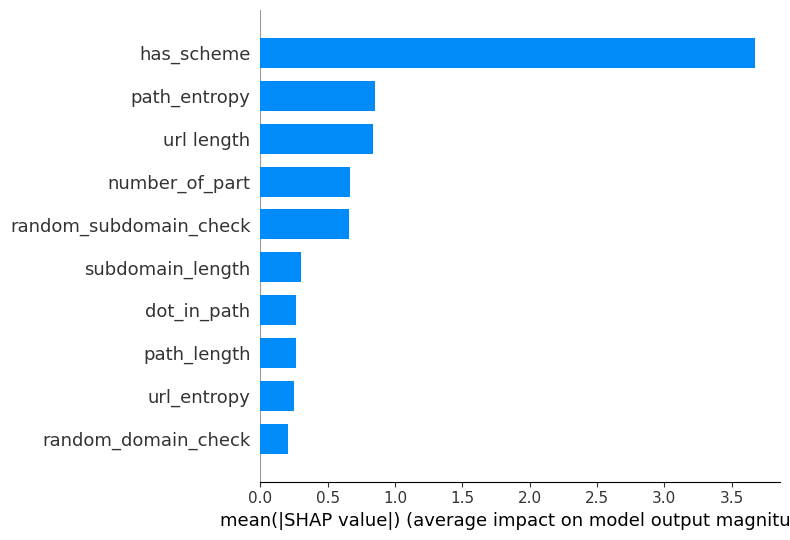


--- defacement ---


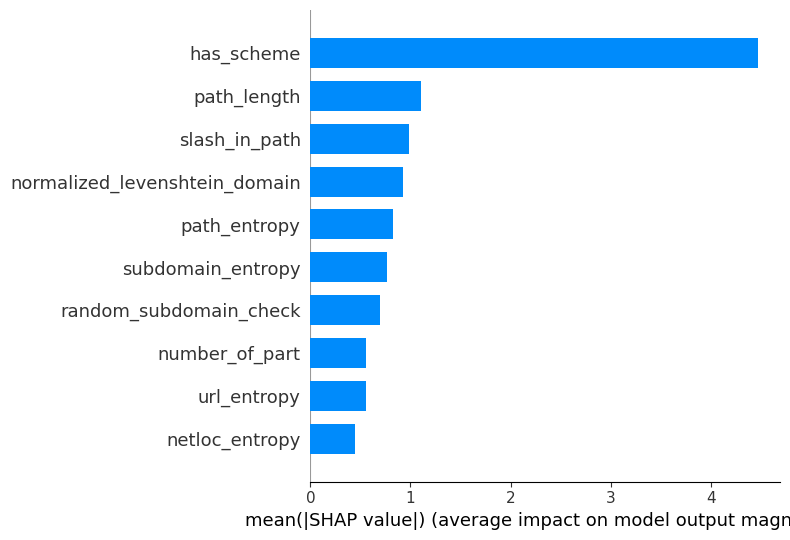


--- malware ---


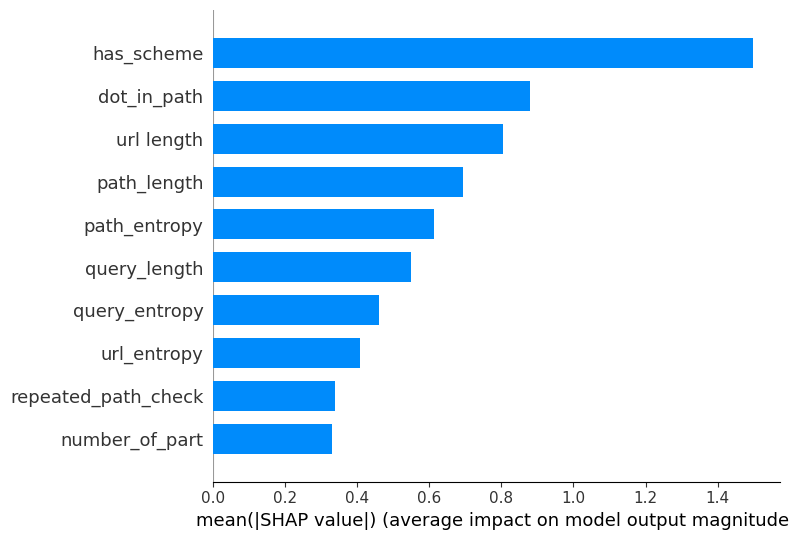


--- phishing ---


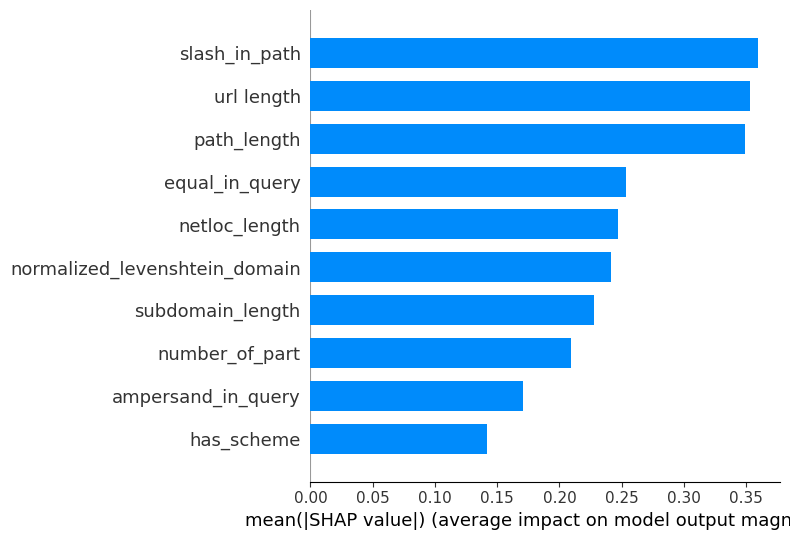

In [10]:
import shap

explainer = shap.TreeExplainer(model_classification)
shap_values = explainer.shap_values(X_test)

# Top features ảnh hưởng nhất với từng lớp
for i, class_name in enumerate(le.classes_):
    print(f"\n--- {class_name} ---")
    shap.summary_plot(
        shap_values[:,:,i], X_test,
        feature_names=X_test.columns,
        plot_type='bar',
        show=True,
        max_display=10
    )